# MovieLens Recommender System: Collaborative Filtering, Matrix Factorization, and Hybrid Bonus Model

## What this notebook includes

| Section | Purpose |
| --- | --- |
| Data loading + EDA | Understand users, movies, ratings, sparsity, and genres |
| Baselines | Global mean, user mean, item mean, and bias baseline |
| Collaborative filtering | Item-based KNN recommender |
| Matrix factorization | Custom NumPy SGD implementation |
| Bonus metric | Precision@K and Recall@K |
| Bonus hybrid model | Matrix factorization + genre similarity + popularity |
| Demo | Select a user and display liked movies plus top recommendations |

In [1]:
# Cell 1: Imports and notebook settings

from pathlib import Path
import math
import os
import warnings

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "ml-latest-small"

# Keep Matplotlib cache inside the repo so the notebook works in restricted environments.
MPL_CACHE_DIR = PROJECT_ROOT / ".cache" / "matplotlib"
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory exists: {DATA_DIR.exists()}")

Project root: /home/dawit/Documents/Trainings/Training-week14
Data directory exists: True


In [2]:
# Cell 2: Load MovieLens files

ratings = pd.read_csv(DATA_DIR / "ratings.csv")
movies = pd.read_csv(DATA_DIR / "movies.csv")
tags = pd.read_csv(DATA_DIR / "tags.csv")
links = pd.read_csv(DATA_DIR / "links.csv")

ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")

print("ratings:", ratings.shape)
print("movies:", movies.shape)
print("tags:", tags.shape)
print("links:", links.shape)

ratings.head()

ratings: (100836, 4)
movies: (9742, 3)
tags: (3683, 4)
links: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [3]:
# Cell 3: Basic dataset summary

n_users = ratings["userId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_movies_total = movies["movieId"].nunique()
n_ratings = len(ratings)
possible_ratings = n_users * n_movies_rated
sparsity = 1 - (n_ratings / possible_ratings)

summary = pd.DataFrame({
    "metric": [
        "Users",
        "Movies in catalog",
        "Movies with at least one rating",
        "Ratings",
        "Average rating",
        "User-item matrix sparsity",
    ],
    "value": [
        n_users,
        n_movies_total,
        n_movies_rated,
        n_ratings,
        round(ratings["rating"].mean(), 3),
        f"{sparsity:.2%}",
    ],
})

summary

,metric,value
0,Users,610
1,Movies in catalog,9742
2,Movies with at least one rating,9724
3,Ratings,100836
4,Average rating,3.502
5,User-item matrix sparsity,98.30%


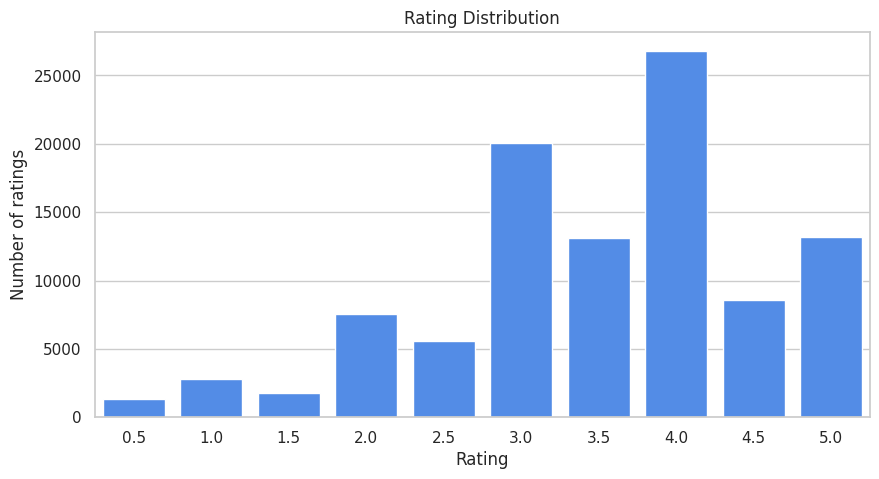

,count,mean,std,min,25%,50%,75%,max
rating,100836.0,3.501557,1.042529,0.5,3.0,3.5,4.0,5.0


In [4]:
# Cell 4: Rating distribution

ax = sns.countplot(data=ratings, x="rating", color="#3A86FF")
ax.set_title("Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of ratings")
plt.show()

ratings["rating"].describe().to_frame().T

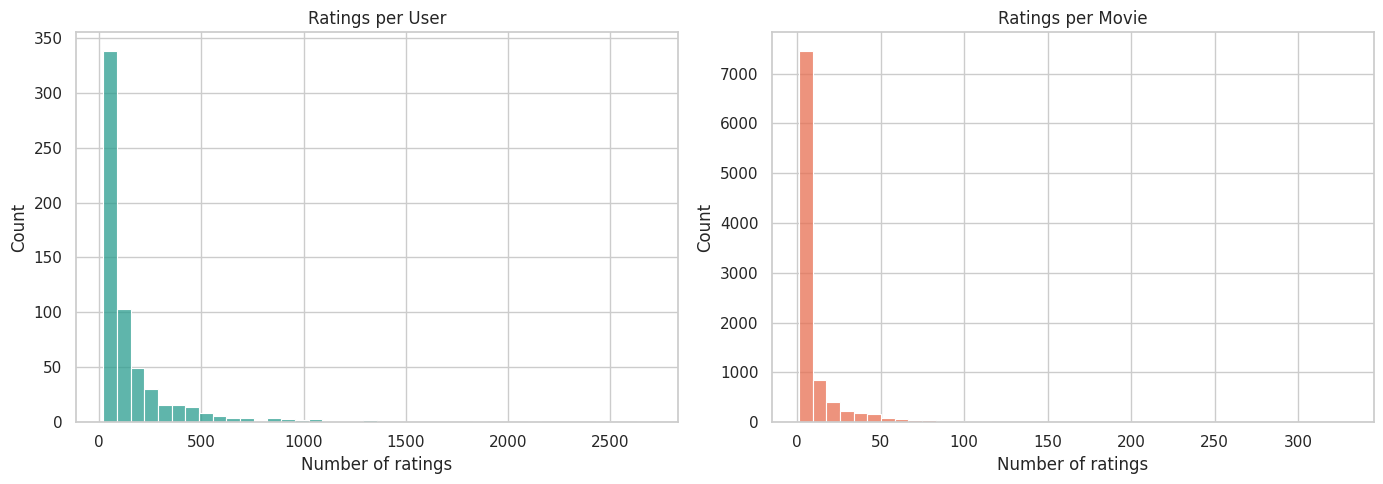

,ratings_per_user,ratings_per_movie
count,610.000000,9724.000000
mean,165.304918,10.369807
std,269.480584,22.401005
min,20.000000,1.000000
25%,35.000000,1.000000
50%,70.500000,3.000000
75%,168.000000,9.000000
max,2698.000000,329.000000


In [5]:
# Cell 5: User and movie activity distributions

user_activity = ratings.groupby("userId").size().rename("ratings_per_user")
movie_activity = ratings.groupby("movieId").size().rename("ratings_per_movie")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(user_activity, bins=40, ax=axes[0], color="#2A9D8F")
axes[0].set_title("Ratings per User")
axes[0].set_xlabel("Number of ratings")

sns.histplot(movie_activity, bins=40, ax=axes[1], color="#E76F51")
axes[1].set_title("Ratings per Movie")
axes[1].set_xlabel("Number of ratings")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "ratings_per_user": user_activity.describe(),
    "ratings_per_movie": movie_activity.describe(),
})

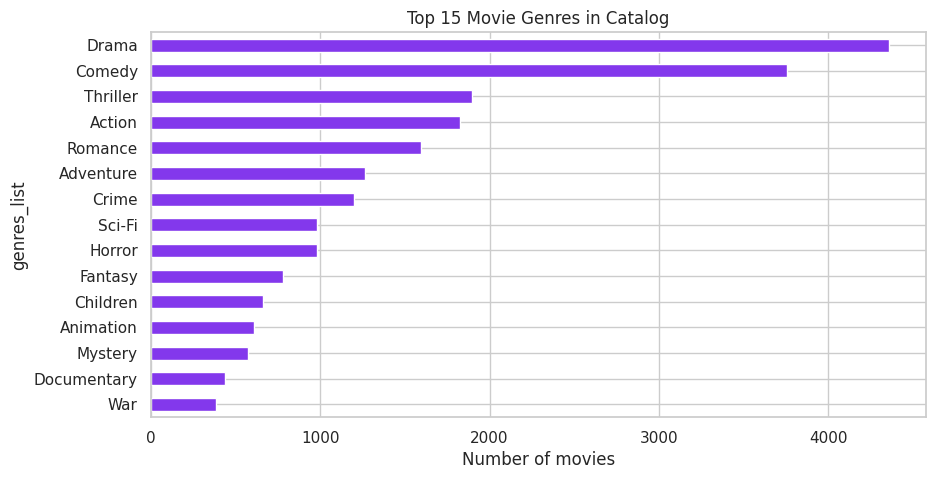

,movieId,title,genres,genres_list,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",1995.0
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]",1995.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]",1995.0
4,5,Father of the Bride Part II (1995),Comedy,[Comedy],1995.0


In [6]:
# Cell 6: Genre preparation and genre popularity

movies_features = movies.copy()
movies_features["genres_list"] = movies_features["genres"].str.split("|")
movies_features["year"] = movies_features["title"].str.extract(r"\((\d{4})\)").astype(float)

movie_genres = movies_features[["movieId", "genres_list"]].explode("genres_list")
genre_counts = movie_genres["genres_list"].value_counts().drop(labels=["(no genres listed)"], errors="ignore")

ax = genre_counts.head(15).sort_values().plot(kind="barh", color="#8338EC")
ax.set_title("Top 15 Movie Genres in Catalog")
ax.set_xlabel("Number of movies")
plt.show()

movies_features.head()

In [7]:
# Cell 7: Train-test split

# A normal random split is simple and acceptable for RMSE evaluation.
# We keep user/movie IDs unchanged so the demo can map predictions back to titles.
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("Train ratings:", train_ratings.shape)
print("Test ratings:", test_ratings.shape)
print("Train users:", train_ratings["userId"].nunique())
print("Test users:", test_ratings["userId"].nunique())

Train ratings: (80668, 4)
Test ratings: (20168, 4)
Train users: 610
Test users: 610


In [8]:
# Cell 8: RMSE helper

def rmse(y_true, y_pred):
    """Return root mean squared error."""
    return math.sqrt(mean_squared_error(y_true, y_pred))

results = []

def add_result(model_name, y_true, y_pred, notes):
    """Store model RMSE in a shared results table."""
    score = rmse(y_true, y_pred)
    results.append({"model": model_name, "rmse": score, "notes": notes})
    return score

In [9]:
# Cell 9: Baseline 1 - global mean model

# This predicts the same average rating for every user/movie pair.
global_mean = train_ratings["rating"].mean()
global_pred = np.full(len(test_ratings), global_mean)

global_rmse = add_result(
    "Global mean baseline",
    test_ratings["rating"],
    global_pred,
    "Predicts the training average for every rating.",
)

print(f"Global mean: {global_mean:.4f}")
print(f"Global mean RMSE: {global_rmse:.4f}")

Global mean: 3.5026
Global mean RMSE: 1.0488


In [10]:
# Cell 10: Baseline 2 - user mean and item mean models

user_means = train_ratings.groupby("userId")["rating"].mean()
item_means = train_ratings.groupby("movieId")["rating"].mean()

user_mean_pred = test_ratings["userId"].map(user_means).fillna(global_mean).to_numpy()
item_mean_pred = test_ratings["movieId"].map(item_means).fillna(global_mean).to_numpy()

user_mean_rmse = add_result(
    "User mean baseline",
    test_ratings["rating"],
    user_mean_pred,
    "Predicts each user's average rating; falls back to global mean.",
)
item_mean_rmse = add_result(
    "Item mean baseline",
    test_ratings["rating"],
    item_mean_pred,
    "Predicts each movie's average rating; falls back to global mean.",
)

print(f"User mean RMSE: {user_mean_rmse:.4f}")
print(f"Item mean RMSE: {item_mean_rmse:.4f}")

User mean RMSE: 0.9497
Item mean RMSE: 0.9827


In [11]:
# Cell 11: Baseline 3 - user + item bias model

# Bias model intuition:
# prediction = global average + user tendency + item tendency
user_bias = train_ratings.groupby("userId")["rating"].mean() - global_mean
item_bias = train_ratings.groupby("movieId")["rating"].mean() - global_mean

bias_pred = (
    global_mean
    + test_ratings["userId"].map(user_bias).fillna(0)
    + test_ratings["movieId"].map(item_bias).fillna(0)
).clip(0.5, 5.0).to_numpy()

bias_rmse = add_result(
    "User + item bias baseline",
    test_ratings["rating"],
    bias_pred,
    "Adds user rating tendency and movie popularity/quality tendency.",
)

print(f"Bias baseline RMSE: {bias_rmse:.4f}")

Bias baseline RMSE: 0.9149


In [12]:
# Cell 12: Build ID mappings and sparse train matrix

# Matrix rows are users, columns are movies. Values are ratings.
user_ids = np.sort(ratings["userId"].unique())
movie_ids = np.sort(movies["movieId"].unique())

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}
idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}

train_user_idx = train_ratings["userId"].map(user_to_idx).to_numpy()
train_movie_idx = train_ratings["movieId"].map(movie_to_idx).to_numpy()
train_values = train_ratings["rating"].to_numpy()

user_item_train = csr_matrix(
    (train_values, (train_user_idx, train_movie_idx)),
    shape=(len(user_ids), len(movie_ids)),
)

item_user_train = user_item_train.T.tocsr()

print("User-item sparse matrix shape:", user_item_train.shape)
print("Known train ratings:", user_item_train.nnz)

User-item sparse matrix shape: (610, 9742)
Known train ratings: 80668


In [13]:
# Cell 13: Collaborative filtering model - item-based KNN

# Item-based KNN finds movies with similar rating patterns.
# We precompute neighbors for every movie once so later predictions are fast.
N_KNN_NEIGHBORS = 41

knn_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=N_KNN_NEIGHBORS,
    n_jobs=-1,
)
knn_model.fit(item_user_train)

item_neighbor_distances, item_neighbor_indices = knn_model.kneighbors(item_user_train)

print("Item-based KNN model fitted.")
print("Precomputed neighbor table shape:", item_neighbor_indices.shape)

Item-based KNN model fitted.
Precomputed neighbor table shape: (9742, 41)


In [14]:
# Cell 14: Predict ratings with item-based KNN

def predict_item_knn(user_id, movie_id, n_neighbors=30):
    """Predict one rating using the user's ratings for similar movies."""
    if user_id not in user_to_idx or movie_id not in movie_to_idx:
        return global_mean

    uidx = user_to_idx[user_id]
    midx = movie_to_idx[movie_id]

    indices = item_neighbor_indices[midx]
    distances = item_neighbor_distances[midx]

    # Drop the target movie itself if it appears as the nearest neighbor.
    mask = indices != midx
    neighbor_indices = indices[mask][:n_neighbors]
    neighbor_distances = distances[mask][:n_neighbors]

    user_ratings_for_neighbors = user_item_train[uidx, neighbor_indices].toarray().ravel()
    rated_mask = user_ratings_for_neighbors > 0

    if rated_mask.sum() == 0:
        return item_means.get(movie_id, global_mean)

    similarities = 1 - neighbor_distances[rated_mask]
    ratings_for_neighbors = user_ratings_for_neighbors[rated_mask]

    if similarities.sum() <= 1e-8:
        return ratings_for_neighbors.mean()

    pred = np.dot(similarities, ratings_for_neighbors) / similarities.sum()
    return float(np.clip(pred, 0.5, 5.0))

# Full-test KNN can be slow in a live presentation, so we evaluate a fixed sample.
# RMSE is still meaningful because the sample is random and reproducible.
knn_test_sample = test_ratings.sample(n=min(5000, len(test_ratings)), random_state=RANDOM_STATE)
knn_pred = np.array([
    predict_item_knn(row.userId, row.movieId)
    for row in knn_test_sample.itertuples(index=False)
])

knn_rmse = add_result(
    "Item-based KNN collaborative filtering",
    knn_test_sample["rating"],
    knn_pred,
    "Uses sparse cosine nearest neighbors between movies; evaluated on a reproducible test sample.",
)

print(f"Item-based KNN sample size: {len(knn_test_sample)}")
print(f"Item-based KNN RMSE: {knn_rmse:.4f}")

Item-based KNN sample size: 5000
Item-based KNN RMSE: 0.9509


In [15]:
# Cell 15: Matrix factorization model class

class MatrixFactorizationSGD:
    """Matrix factorization with user/item biases trained by SGD."""

    def __init__(self, n_factors=50, n_epochs=18, lr=0.008, reg=0.04, random_state=42):
        self.n_factors = n_factors
        self.n_epochs = n_epochs
        self.lr = lr
        self.reg = reg
        self.random_state = random_state

    def fit(self, train_df, user_to_idx, movie_to_idx, global_mean):
        self.user_to_idx = user_to_idx
        self.movie_to_idx = movie_to_idx
        self.global_mean = global_mean
        self.n_users = len(user_to_idx)
        self.n_movies = len(movie_to_idx)

        rng = np.random.default_rng(self.random_state)
        self.P = rng.normal(0, 0.1, size=(self.n_users, self.n_factors))
        self.Q = rng.normal(0, 0.1, size=(self.n_movies, self.n_factors))
        self.bu = np.zeros(self.n_users)
        self.bi = np.zeros(self.n_movies)
        self.training_history = []

        rows = train_df[["userId", "movieId", "rating"]].copy()
        rows["uidx"] = rows["userId"].map(user_to_idx)
        rows["midx"] = rows["movieId"].map(movie_to_idx)
        samples = rows[["uidx", "midx", "rating"]].to_numpy()

        for epoch in range(1, self.n_epochs + 1):
            rng.shuffle(samples)
            squared_errors = []

            for uidx, midx, rating in samples:
                uidx = int(uidx)
                midx = int(midx)

                pred = self._predict_idx(uidx, midx)
                err = rating - pred
                squared_errors.append(err ** 2)

                old_p = self.P[uidx].copy()
                old_q = self.Q[midx].copy()

                self.bu[uidx] += self.lr * (err - self.reg * self.bu[uidx])
                self.bi[midx] += self.lr * (err - self.reg * self.bi[midx])
                self.P[uidx] += self.lr * (err * old_q - self.reg * old_p)
                self.Q[midx] += self.lr * (err * old_p - self.reg * old_q)

            epoch_rmse = math.sqrt(np.mean(squared_errors))
            self.training_history.append({"epoch": epoch, "train_rmse": epoch_rmse})
            print(f"Epoch {epoch:02d}/{self.n_epochs} - train RMSE: {epoch_rmse:.4f}")

        return self

    def _predict_idx(self, uidx, midx):
        return self.global_mean + self.bu[uidx] + self.bi[midx] + np.dot(self.P[uidx], self.Q[midx])

    def predict_one(self, user_id, movie_id):
        if user_id not in self.user_to_idx and movie_id not in self.movie_to_idx:
            return self.global_mean
        if user_id not in self.user_to_idx:
            return self.global_mean + item_bias.get(movie_id, 0)
        if movie_id not in self.movie_to_idx:
            return self.global_mean + user_bias.get(user_id, 0)

        uidx = self.user_to_idx[user_id]
        midx = self.movie_to_idx[movie_id]
        pred = self._predict_idx(uidx, midx)
        return float(np.clip(pred, 0.5, 5.0))

    def predict(self, df):
        return np.array([self.predict_one(row.userId, row.movieId) for row in df.itertuples(index=False)])

In [16]:
# Cell 16: Train and evaluate matrix factorization

mf_model = MatrixFactorizationSGD(
    n_factors=60,
    n_epochs=12,
    lr=0.008,
    reg=0.04,
    random_state=RANDOM_STATE,
)

mf_model.fit(train_ratings, user_to_idx, movie_to_idx, global_mean)
mf_pred = mf_model.predict(test_ratings)

mf_rmse = add_result(
    "Matrix factorization SGD",
    test_ratings["rating"],
    mf_pred,
    "Custom latent-factor model with user/item biases.",
)

print(f"Matrix factorization RMSE: {mf_rmse:.4f}")

Epoch 01/12 - train RMSE: 0.9508


Epoch 02/12 - train RMSE: 0.8926


Epoch 03/12 - train RMSE: 0.8690


Epoch 04/12 - train RMSE: 0.8531


Epoch 05/12 - train RMSE: 0.8403


...

Epoch 08/12 - train RMSE: 0.8090


Epoch 09/12 - train RMSE: 0.7992


Epoch 10/12 - train RMSE: 0.7890


Epoch 11/12 - train RMSE: 0.7784


Epoch 12/12 - train RMSE: 0.7671
Matrix factorization RMSE: 0.8806


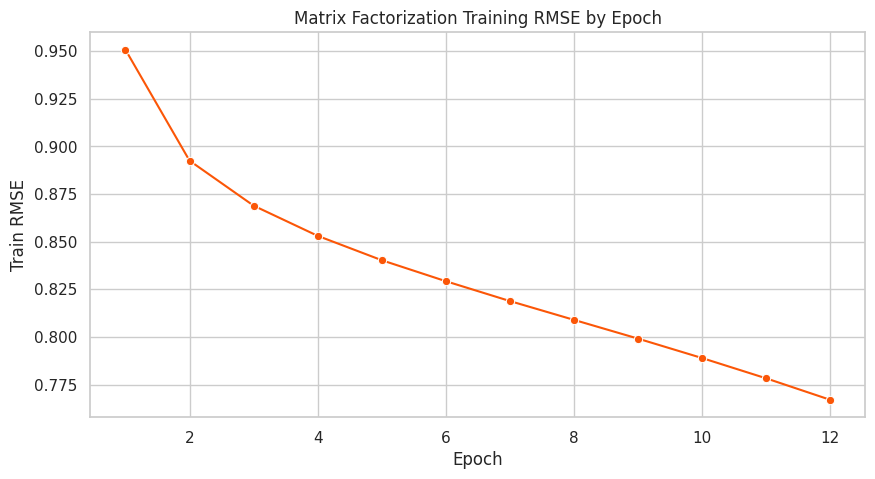

,epoch,train_rmse
7,8,0.809039
8,9,0.799201
9,10,0.789014
10,11,0.778373
11,12,0.767104


In [17]:
# Cell 17: Plot matrix factorization training curve

history_df = pd.DataFrame(mf_model.training_history)

ax = sns.lineplot(data=history_df, x="epoch", y="train_rmse", marker="o", color="#FB5607")
ax.set_title("Matrix Factorization Training RMSE by Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Train RMSE")
plt.show()

history_df.tail()

,model,rmse,notes
0,Matrix factorization SGD,0.880632,Custom latent-factor model with user/item biases.
1,User + item bias baseline,0.914894,Adds user rating tendency and movie popularity...
2,User mean baseline,0.949747,Predicts each user's average rating; falls bac...
3,Item-based KNN collaborative filtering,0.950934,Uses sparse cosine nearest neighbors between m...
4,Item mean baseline,0.982739,Predicts each movie's average rating; falls ba...
5,Global mean baseline,1.048841,Predicts the training average for every rating.


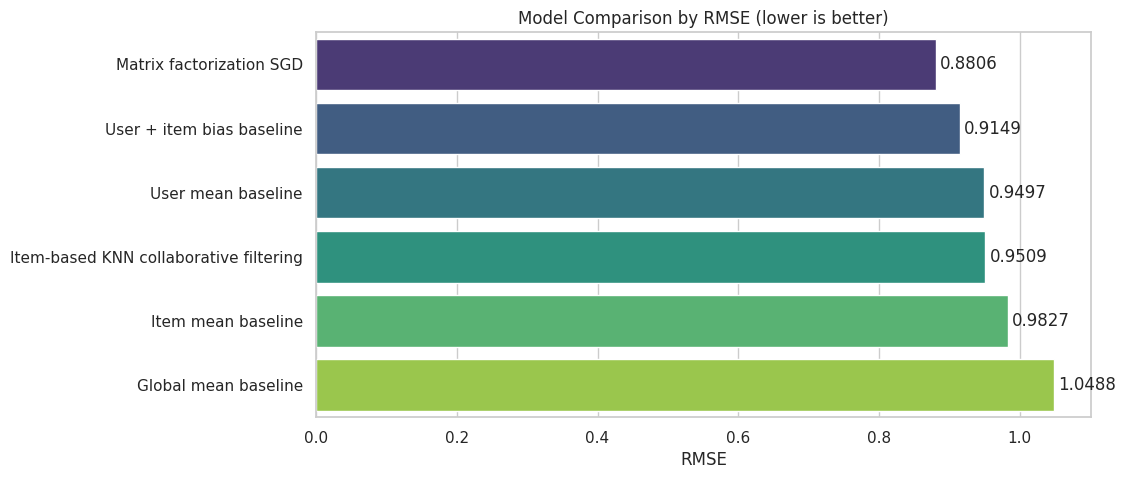

In [18]:
# Cell 18: RMSE comparison table and chart

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
display(results_df)

ax = sns.barplot(data=results_df, y="model", x="rmse", palette="viridis")
ax.set_title("Model Comparison by RMSE (lower is better)")
ax.set_xlabel("RMSE")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
plt.show()

In [19]:
# Cell 19: Prepare recommendation candidates and helper functions

movie_info = movies_features.set_index("movieId")
rated_by_user_train = train_ratings.groupby("userId")["movieId"].apply(set).to_dict()
all_movie_ids = set(movies["movieId"])

movie_rating_stats = train_ratings.groupby("movieId").agg(
    mean_rating=("rating", "mean"),
    rating_count=("rating", "size"),
).reset_index()

# Popularity score is scaled rating_count. We use this inside the hybrid model.
movie_rating_stats["popularity_score"] = MinMaxScaler().fit_transform(movie_rating_stats[["rating_count"]])
movie_stats = movie_rating_stats.set_index("movieId")


def get_unseen_movies(user_id, minimum_rating_count=5):
    """Return movies the user has not rated in the training data."""
    seen = rated_by_user_train.get(user_id, set())
    candidates = list(all_movie_ids - seen)
    if minimum_rating_count > 0:
        active_movies = set(movie_rating_stats.loc[movie_rating_stats["rating_count"] >= minimum_rating_count, "movieId"])
        candidates = [movie_id for movie_id in candidates if movie_id in active_movies]
    return candidates


def get_user_liked_movies(user_id, min_rating=4.0, limit=10):
    """Return movies a user liked in the training data."""
    liked = train_ratings[(train_ratings["userId"] == user_id) & (train_ratings["rating"] >= min_rating)]
    liked = liked.merge(movies, on="movieId", how="left").sort_values("rating", ascending=False)
    return liked[["movieId", "title", "genres", "rating"]].head(limit)

In [20]:
# Cell 20: Genre profile and hybrid score helpers

# Create one-hot genre matrix for content-aware bonus scoring.
genre_dummies = movies_features["genres"].str.get_dummies(sep="|")
genre_dummies = genre_dummies.drop(columns=["(no genres listed)"], errors="ignore")
genre_dummies.index = movies_features["movieId"]

user_genre_profile_cache = {}


def build_user_genre_profile(user_id, min_rating=3.5):
    """Build a user's genre preference vector from positive training ratings."""
    cache_key = (user_id, min_rating)
    if cache_key in user_genre_profile_cache:
        return user_genre_profile_cache[cache_key]

    user_history = train_ratings[train_ratings["userId"] == user_id]
    user_history = user_history[user_history["rating"] >= min_rating]

    if user_history.empty:
        profile = pd.Series(np.zeros(genre_dummies.shape[1]), index=genre_dummies.columns)
        user_genre_profile_cache[cache_key] = profile
        return profile

    available_movie_ids = [movie_id for movie_id in user_history["movieId"] if movie_id in genre_dummies.index]
    weights = user_history.set_index("movieId").loc[available_movie_ids, "rating"]
    weighted_genres = genre_dummies.loc[available_movie_ids].multiply(weights, axis=0)
    profile = weighted_genres.sum(axis=0)

    if profile.sum() > 0:
        profile = profile / profile.sum()

    user_genre_profile_cache[cache_key] = profile
    return profile


def genre_similarity_score(user_id, movie_id):
    """Score how well a movie's genres match the user's genre profile."""
    if movie_id not in genre_dummies.index:
        return 0.0

    profile = build_user_genre_profile(user_id)
    movie_vector = genre_dummies.loc[movie_id]
    score = float(np.dot(profile, movie_vector))
    return score


def hybrid_score(user_id, movie_id, mf_weight=0.70, genre_weight=0.20, popularity_weight=0.10):
    """Combine matrix factorization, genre similarity, and popularity."""
    mf_score = (mf_model.predict_one(user_id, movie_id) - 0.5) / 4.5
    genre_score = genre_similarity_score(user_id, movie_id)
    popularity_score = movie_stats.loc[movie_id, "popularity_score"] if movie_id in movie_stats.index else 0.0

    combined = (mf_weight * mf_score) + (genre_weight * genre_score) + (popularity_weight * popularity_score)
    return float(combined)

In [21]:
# Cell 21: Generate Top-K recommendations for a user

def recommend_for_user(user_id, model="hybrid", k=10, minimum_rating_count=20, candidate_limit=1200):
    """Return top K unseen movie recommendations for a user."""
    candidates = get_unseen_movies(user_id, minimum_rating_count=minimum_rating_count)

    # Keep demos and ranking evaluation fast by scoring the most-rated candidate movies first.
    if len(candidates) > candidate_limit:
        candidate_rank = movie_rating_stats.set_index("movieId").loc[
            [movie_id for movie_id in candidates if movie_id in movie_stats.index],
            "rating_count",
        ].sort_values(ascending=False)
        candidates = candidate_rank.head(candidate_limit).index.tolist()

    rows = []
    for movie_id in candidates:
        if model == "mf":
            score = mf_model.predict_one(user_id, movie_id)
        elif model == "knn":
            score = predict_item_knn(user_id, movie_id)
        elif model == "hybrid":
            score = hybrid_score(user_id, movie_id)
        else:
            score = item_means.get(movie_id, global_mean)

        rows.append({"movieId": movie_id, "score": score})

    recs = pd.DataFrame(rows).sort_values("score", ascending=False).head(k)
    recs = recs.merge(movies, on="movieId", how="left")
    recs = recs.merge(movie_rating_stats, on="movieId", how="left")
    return recs[["movieId", "title", "genres", "score", "mean_rating", "rating_count"]]

sample_user = int(train_ratings["userId"].value_counts().index[0])
print("Sample user:", sample_user)
recommend_for_user(sample_user, model="hybrid", k=10)

Sample user: 414


,movieId,title,genres,score,mean_rating,rating_count
0,608,Fargo (1996),Comedy|Crime|Drama|Thriller,0.702746,4.111111,144
1,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,0.686511,4.106383,141
2,1208,Apocalypse Now (1979),Action|Drama|War,0.686244,4.164706,85
3,1221,"Godfather: Part II, The (1974)",Crime|Drama,0.678095,4.268868,106
4,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,0.673627,4.091549,71
5,48516,"Departed, The (2006)",Crime|Drama|Thriller,0.662955,4.269231,91
6,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,0.662409,4.219136,162
7,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,0.660958,4.354167,24
8,1247,"Graduate, The (1967)",Comedy|Drama|Romance,0.653929,4.026316,57
9,914,My Fair Lady (1964),Comedy|Drama|Musical|Romance,0.651579,4.071429,28


In [22]:
# Cell 22: Bonus evaluation - Precision@K and Recall@K

# Relevance rule: a movie is relevant if the user rated it at least 4.0 in the test set.
# We evaluate a fixed user sample so this cell stays fast enough for a live notebook demo.

def precision_recall_at_k(model_name="hybrid", k=10, min_test_rating=4.0, max_users=40):
    relevant_test = test_ratings[test_ratings["rating"] >= min_test_rating]
    user_to_relevant = relevant_test.groupby("userId")["movieId"].apply(set).to_dict()
    eval_users = list(user_to_relevant.keys())[:max_users]

    precisions = []
    recalls = []

    for user_id in eval_users:
        recs = recommend_for_user(user_id, model=model_name, k=k, minimum_rating_count=20, candidate_limit=1000)
        recommended = set(recs["movieId"])
        relevant = user_to_relevant[user_id]

        hits = len(recommended & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))

    return {
        "model": model_name,
        "k": k,
        "evaluated_users": len(eval_users),
        "precision_at_k": float(np.mean(precisions)) if precisions else 0.0,
        "recall_at_k": float(np.mean(recalls)) if recalls else 0.0,
    }

ranking_results = pd.DataFrame([
    precision_recall_at_k("baseline", k=10),
    precision_recall_at_k("knn", k=10),
    precision_recall_at_k("mf", k=10),
    precision_recall_at_k("hybrid", k=10),
])

ranking_results

,model,k,evaluated_users,precision_at_k,recall_at_k
0,baseline,10,40,0.0225,0.033061
1,knn,10,40,0.0075,0.028987
2,mf,10,40,0.0375,0.025893
3,hybrid,10,40,0.0900,0.051996


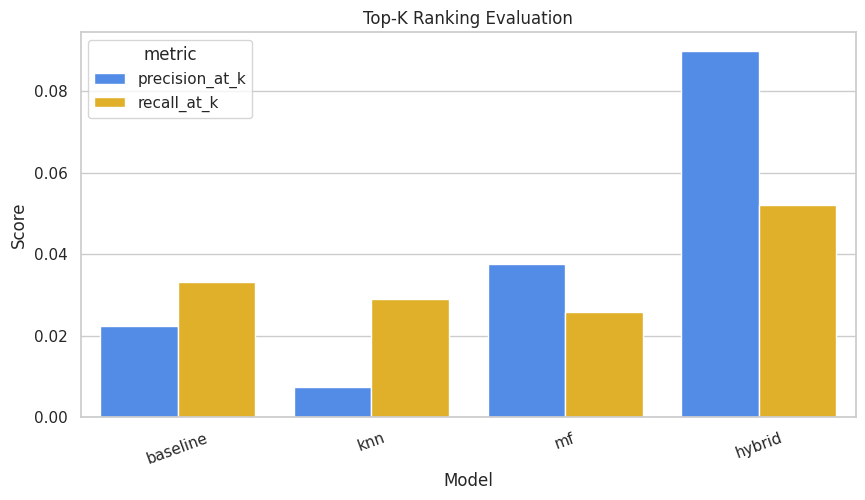

In [23]:
# Cell 23: Ranking metric chart

ranking_long = ranking_results.melt(
    id_vars=["model", "k", "evaluated_users"],
    value_vars=["precision_at_k", "recall_at_k"],
    var_name="metric",
    value_name="score",
)

ax = sns.barplot(data=ranking_long, x="model", y="score", hue="metric", palette=["#3A86FF", "#FFBE0B"])
ax.set_title("Top-K Ranking Evaluation")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.show()

In [24]:
# Cell 24: Demo helper - explain a recommendation list

def explain_recommendations(user_id, model="hybrid", k=10):
    """Show what the user liked and what the recommender suggests."""
    print(f"Demo user: {user_id}")
    print("\nMovies this user liked in training data:")
    liked = get_user_liked_movies(user_id, min_rating=4.0, limit=8)
    display(liked)

    print(f"\nTop {k} {model.upper()} recommendations:")
    recs = recommend_for_user(user_id, model=model, k=k)
    display(recs)

    profile = build_user_genre_profile(user_id).sort_values(ascending=False).head(8)
    print("\nTop learned genre preferences:")
    display(profile.to_frame("preference_weight"))

    return recs

# Pick a user with many ratings so the demo is interesting.
demo_user = int(train_ratings["userId"].value_counts().head(20).sample(1, random_state=RANDOM_STATE).index[0])
demo_recs = explain_recommendations(demo_user, model="hybrid", k=10)

Demo user: 414

Movies this user liked in training data:


,movieId,title,genres,rating
822,1243,Rosencrantz and Guildenstern Are Dead (1990),Comedy|Drama,5.0
820,3363,American Graffiti (1973),Comedy|Drama,5.0
194,5292,Slap Shot (1977),Comedy,5.0
819,4022,Cast Away (2000),Drama,5.0
650,3578,Gladiator (2000),Action|Adventure|Drama,5.0
201,2959,Fight Club (1999),Action|Crime|Drama|Thriller,5.0
438,4002,"Planes, Trains & Automobiles (1987)",Comedy,5.0
203,1266,Unforgiven (1992),Drama|Western,5.0



Top 10 HYBRID recommendations:


,movieId,title,genres,score,mean_rating,rating_count
0,608,Fargo (1996),Comedy|Crime|Drama|Thriller,0.702746,4.111111,144
1,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,0.686511,4.106383,141
2,1208,Apocalypse Now (1979),Action|Drama|War,0.686244,4.164706,85
3,1221,"Godfather: Part II, The (1974)",Crime|Drama,0.678095,4.268868,106
4,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,0.673627,4.091549,71
5,48516,"Departed, The (2006)",Crime|Drama|Thriller,0.662955,4.269231,91
6,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,0.662409,4.219136,162
7,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,0.660958,4.354167,24
8,1247,"Graduate, The (1967)",Comedy|Drama|Romance,0.653929,4.026316,57
9,914,My Fair Lady (1964),Comedy|Drama|Musical|Romance,0.651579,4.071429,28



Top learned genre preferences:


,preference_weight
Drama,0.226017
Comedy,0.143748
Action,0.085600
Thriller,0.082654
Romance,0.075481
Adventure,0.070828
Crime,0.066559
Sci-Fi,0.048841


In [25]:
# Cell 25: interactive demo cell

# This gives a simple notebook-based demo. If widgets do not display in your environment,
# use explain_recommendations(user_id, model="hybrid", k=10) from the previous cell.
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    active_users = sorted(train_ratings["userId"].value_counts().head(100).index.tolist())
    user_dropdown = widgets.Dropdown(options=active_users, value=active_users[0], description="User")
    model_dropdown = widgets.Dropdown(options=["hybrid", "mf", "knn", "baseline"], value="hybrid", description="Model")
    k_slider = widgets.IntSlider(value=10, min=5, max=20, step=1, description="Top K")
    run_button = widgets.Button(description="Recommend", button_style="primary")
    output = widgets.Output()

    def on_click(_):
        with output:
            clear_output(wait=True)
            explain_recommendations(user_dropdown.value, model=model_dropdown.value, k=k_slider.value)

    run_button.on_click(on_click)
    display(widgets.HBox([user_dropdown, model_dropdown, k_slider, run_button]))
    display(output)
except Exception as exc:
    print("Interactive widgets are not available here. Use explain_recommendations(user_id, model='hybrid', k=10).")
    print(exc)

Output()

In [26]:
# Cell 26: Final summary table

best_rmse_model = results_df.iloc[0]
best_precision_model = ranking_results.sort_values("precision_at_k", ascending=False).iloc[0]

final_summary = pd.DataFrame({
    "question": [
        "Best RMSE model",
        "Best Top-K model",
        "Bonus 1 completed",
        "Bonus 2 completed",
        "Demo method",
        "Main limitation",
    ],
    "answer": [
        f"{best_rmse_model['model']} with RMSE {best_rmse_model['rmse']:.4f}",
        f"{best_precision_model['model']} with Precision@{int(best_precision_model['k'])} {best_precision_model['precision_at_k']:.4f}",
        "Precision@K and Recall@K implemented",
        "Hybrid model combines MF + genre similarity + popularity",
        "Notebook demo with user history, top recommendations, and genre explanation",
        "Cold start users/items still need metadata or onboarding signals",
    ],
})

final_summary

,question,answer
0,Best RMSE model,Matrix factorization SGD with RMSE 0.8806
1,Best Top-K model,hybrid with Precision@10 0.0900
2,Bonus 1 completed,Precision@K and Recall@K implemented
3,Bonus 2 completed,Hybrid model combines MF + genre similarity + ...
4,Demo method,"Notebook demo with user history, top recommend..."
5,Main limitation,Cold start users/items still need metadata or ...
